# A/B-тест геймификации на образовательной платформе

**Цель:** оценить влияние системы достижений за регулярное решение задач на Completion Rate и Retention (D7, D14).

**Гипотеза:** геймификация статистически значимо повышает конверсию в полное прохождение модуля и метрики удержания.

**Дизайн эксперимента:**
- Группа A — контроль (старый интерфейс)
- Группа B — тест (геймификация)
- Длительность: 3 недели (04.05.2026 – 24.05.2026)
- Метрики: D7/D14 Retention, Completion Rate, среднее число решённых ДЗ

## 0. Импорты и настройка отображения

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import NormalIndPower
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения графиков и формата чисел
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Загрузка и первичная очистка данных

### 1.1 Datasets INFO

In [2]:
df_groups = pd.read_csv('ab_test_users_groups.csv')
df_events = pd.read_csv('ab_test_events.csv')

df_groups['signup_date'] = pd.to_datetime(df_groups['signup_date'])
df_events['timestamp'] = pd.to_datetime(df_events['timestamp'])

def print_dataset_info(df, name, head=5):
    print(f'============ {name} Datset ============')
    print('Dataset Shape:', df.shape)
    print('Columns:', df.columns.values)
    print('Number of unique users:', df['user_id'].nunique())
    print(f'Head (rows={head}) of Dataset:')
    print(df_groups.head(head)) 
    print(f'=======================================\n')

print_dataset_info(df_groups, "Groups")
print_dataset_info(df_events, "Events")

============ Groups Datset ============
Dataset Shape: (6008, 4)
Columns: ['user_id' 'group' 'signup_date' 'grade']
Number of unique users: 6000
Head (rows=5) of Dataset:
   user_id group signup_date  grade
0  U300000     B  2026-03-09      5
1  U300001     B  2025-09-07      9
2  U300002     B  2026-01-11      9
3  U300003     A  2025-06-07      5
4  U300004     B  2025-12-25     11

============ Events Datset ============
Dataset Shape: (179330, 3)
Columns: ['user_id' 'timestamp' 'event_type']
Number of unique users: 6000
Head (rows=5) of Dataset:
   user_id group signup_date  grade
0  U300000     B  2026-03-09      5
1  U300001     B  2025-09-07      9
2  U300002     B  2026-01-11      9
3  U300003     A  2025-06-07      5
4  U300004     B  2025-12-25     11



In [3]:
import pandas as pd

def print_ab_info(df):
    print(f'\n======================================')
    print('Dataset Shape:', df.shape)
    print('Number Unique user_id:', df['user_id'].nunique())

    info = (
        df.groupby('group')
        .agg(
            n_rows=('user_id', 'count'),
            n_users=('user_id', 'nunique')
        )
    )

    info['n_rows/n_users'] = info['n_rows'] / info['n_users']

    print(info)

    print(f'======================================\n')
    
print_ab_info(df_groups)
print('duplicates:', df_groups['user_id'].duplicated().sum())

if df_groups['user_id'].duplicated().any():
    print('\nДубликаты user_id:')
    print(
        df_groups[
            df_groups['user_id'].duplicated(keep=False)
        ]
        .sort_values('user_id')
    )

df_groups = df_groups.drop_duplicates(
    subset='user_id',
    keep=False
)
print_ab_info(df_groups)

# Здесь же удалится и пересечение между A и B группами, если пересечение есть
# Считаю необходимым удаление повторных вхождений юзеров чтобы не портить статистики в поиске ботов


Dataset Shape: (6008, 4)
Number Unique user_id: 6000
       n_rows  n_users  n_rows/n_users
group                                 
A        3005     3005          1.0000
B        3003     3003          1.0000

duplicates: 8

Дубликаты user_id:
      user_id group signup_date  grade
357   U300357     A  2026-03-19      9
6000  U300357     B  2026-03-19      9
460   U300460     B  2025-08-12      6
6001  U300460     A  2025-08-12      6
920   U300920     B  2025-04-09     10
6002  U300920     A  2025-04-09     10
1014  U301014     A  2026-03-28     10
6003  U301014     B  2026-03-28     10
1087  U301087     B  2025-06-27     10
6004  U301087     A  2025-06-27     10
1367  U301367     B  2025-09-03      8
6005  U301367     A  2025-09-03      8
1554  U301554     A  2025-09-25      9
6006  U301554     B  2025-09-25      9
5216  U305216     B  2025-07-17      9
6007  U305216     A  2025-07-17      9

Dataset Shape: (5992, 4)
Number Unique user_id: 5992
       n_rows  n_users  n_rows/n_users

In [4]:
df = df_events.merge(
    df_groups,
    on='user_id',
    how='left'
)

print_ab_info(df)
print(df.head())


Dataset Shape: (179330, 6)
Number Unique user_id: 6000
       n_rows  n_users  n_rows/n_users
group                                 
A       82915     2997         27.6660
B       96198     2995         32.1195

   user_id           timestamp          event_type group signup_date   grade
0  U300281 2026-05-04 00:06:44  homework_completed     B  2025-08-01 11.0000
1  U300733 2026-05-04 00:19:56  homework_completed     B  2025-07-12  7.0000
2  U304499 2026-05-04 00:22:07               login     A  2025-10-26 11.0000
3  U304266 2026-05-04 00:23:42    homework_started     A  2025-12-30  9.0000
4  U304266 2026-05-04 00:23:42    homework_started     A  2025-12-30  9.0000


### 1.2 Поиск выбросов, аномалий и ботов


=== events_count ===
mean: 29.8883
std:  34.0020
skew: 21.0624
min: 6.0000
max: 842.0000

Quantiles:
0.0010     9.0000
0.0100    14.0000
0.0500    18.0000
0.2500    24.0000
0.5000    28.0000
0.7500    33.0000
0.9500    40.0000
0.9900    45.0100
0.9990   770.0010
Name: events_count, dtype: float64


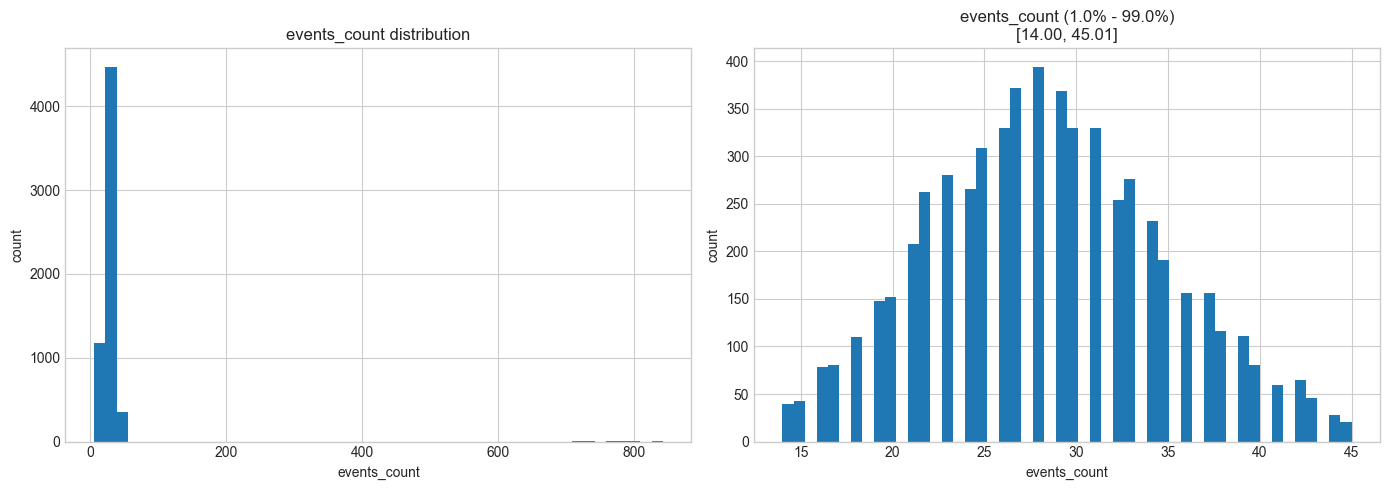

In [5]:
def show_distribution(
    data,
    feature,
    quantile_range=(0.01, 0.99),
    quantiles = [
        0.001,
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99,
        0.999,
    ],
    bins=50,
    figsize=(14, 5)
):
    x = data[feature].dropna()

    quantiles = x.quantile(quantiles)

    print(f'\n=== {feature} ===')
    print(f'mean: {x.mean():.4f}')
    print(f'std:  {x.std():.4f}')
    print(f'skew: {x.skew():.4f}')
    print(f'min: {x.min():.4f}')
    print(f'max: {x.max():.4f}')
    print('\nQuantiles:')
    print(quantiles)
    
    q_left = x.quantile(quantile_range[0])
    q_right = x.quantile(quantile_range[1])

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Полное распределение
    axes[0].hist(x, bins=bins)
    axes[0].set_title(f'{feature} distribution')
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel('count')

    # Обрезанное по квантилям
    x_filtered = x[(x >= q_left) & (x <= q_right)]

    axes[1].hist(x_filtered, bins=bins)
    axes[1].set_title(
        f'{feature} ({quantile_range[0]*100:.1f}% - {quantile_range[1]*100:.1f}%)\n'
        f'[{q_left:.2f}, {q_right:.2f}]'
    )
    axes[1].set_xlabel(feature)
    axes[1].set_ylabel('count')

    plt.tight_layout()
    plt.show()

user_activity = df.groupby('user_id').size().reset_index(name='events_count')

show_distribution(
    user_activity,
    'events_count',
    quantile_range=(0.01, 0.99)
)

In [6]:
# Первая фильтрация 
print_ab_info(df)

BOT_EVENT_SIZE = 100
bots = user_activity[(user_activity['events_count'] > BOT_EVENT_SIZE)]['user_id'].tolist()
bots_idxs = df['user_id'].isin(bots)
users_idxs = ~df['user_id'].isin(bots)

print(f'\nСписок ботов: {bots}' \
      f'\nКоличество ботов: {len(bots)}', '\n')

df_clean = df[users_idxs].copy()

print_ab_info(df_clean)


Dataset Shape: (179330, 6)
Number Unique user_id: 6000
       n_rows  n_users  n_rows/n_users
group                                 
A       82915     2997         27.6660
B       96198     2995         32.1195


Список ботов: ['U300158', 'U300281', 'U300573', 'U300733', 'U302379', 'U302840', 'U303438', 'U303729', 'U304167', 'U304266', 'U304499', 'U305378']
Количество ботов: 12 


Dataset Shape: (170050, 6)
Number Unique user_id: 5988
       n_rows  n_users  n_rows/n_users
group                                 
A       79190     2992         26.4672
B       90643     2988         30.3357



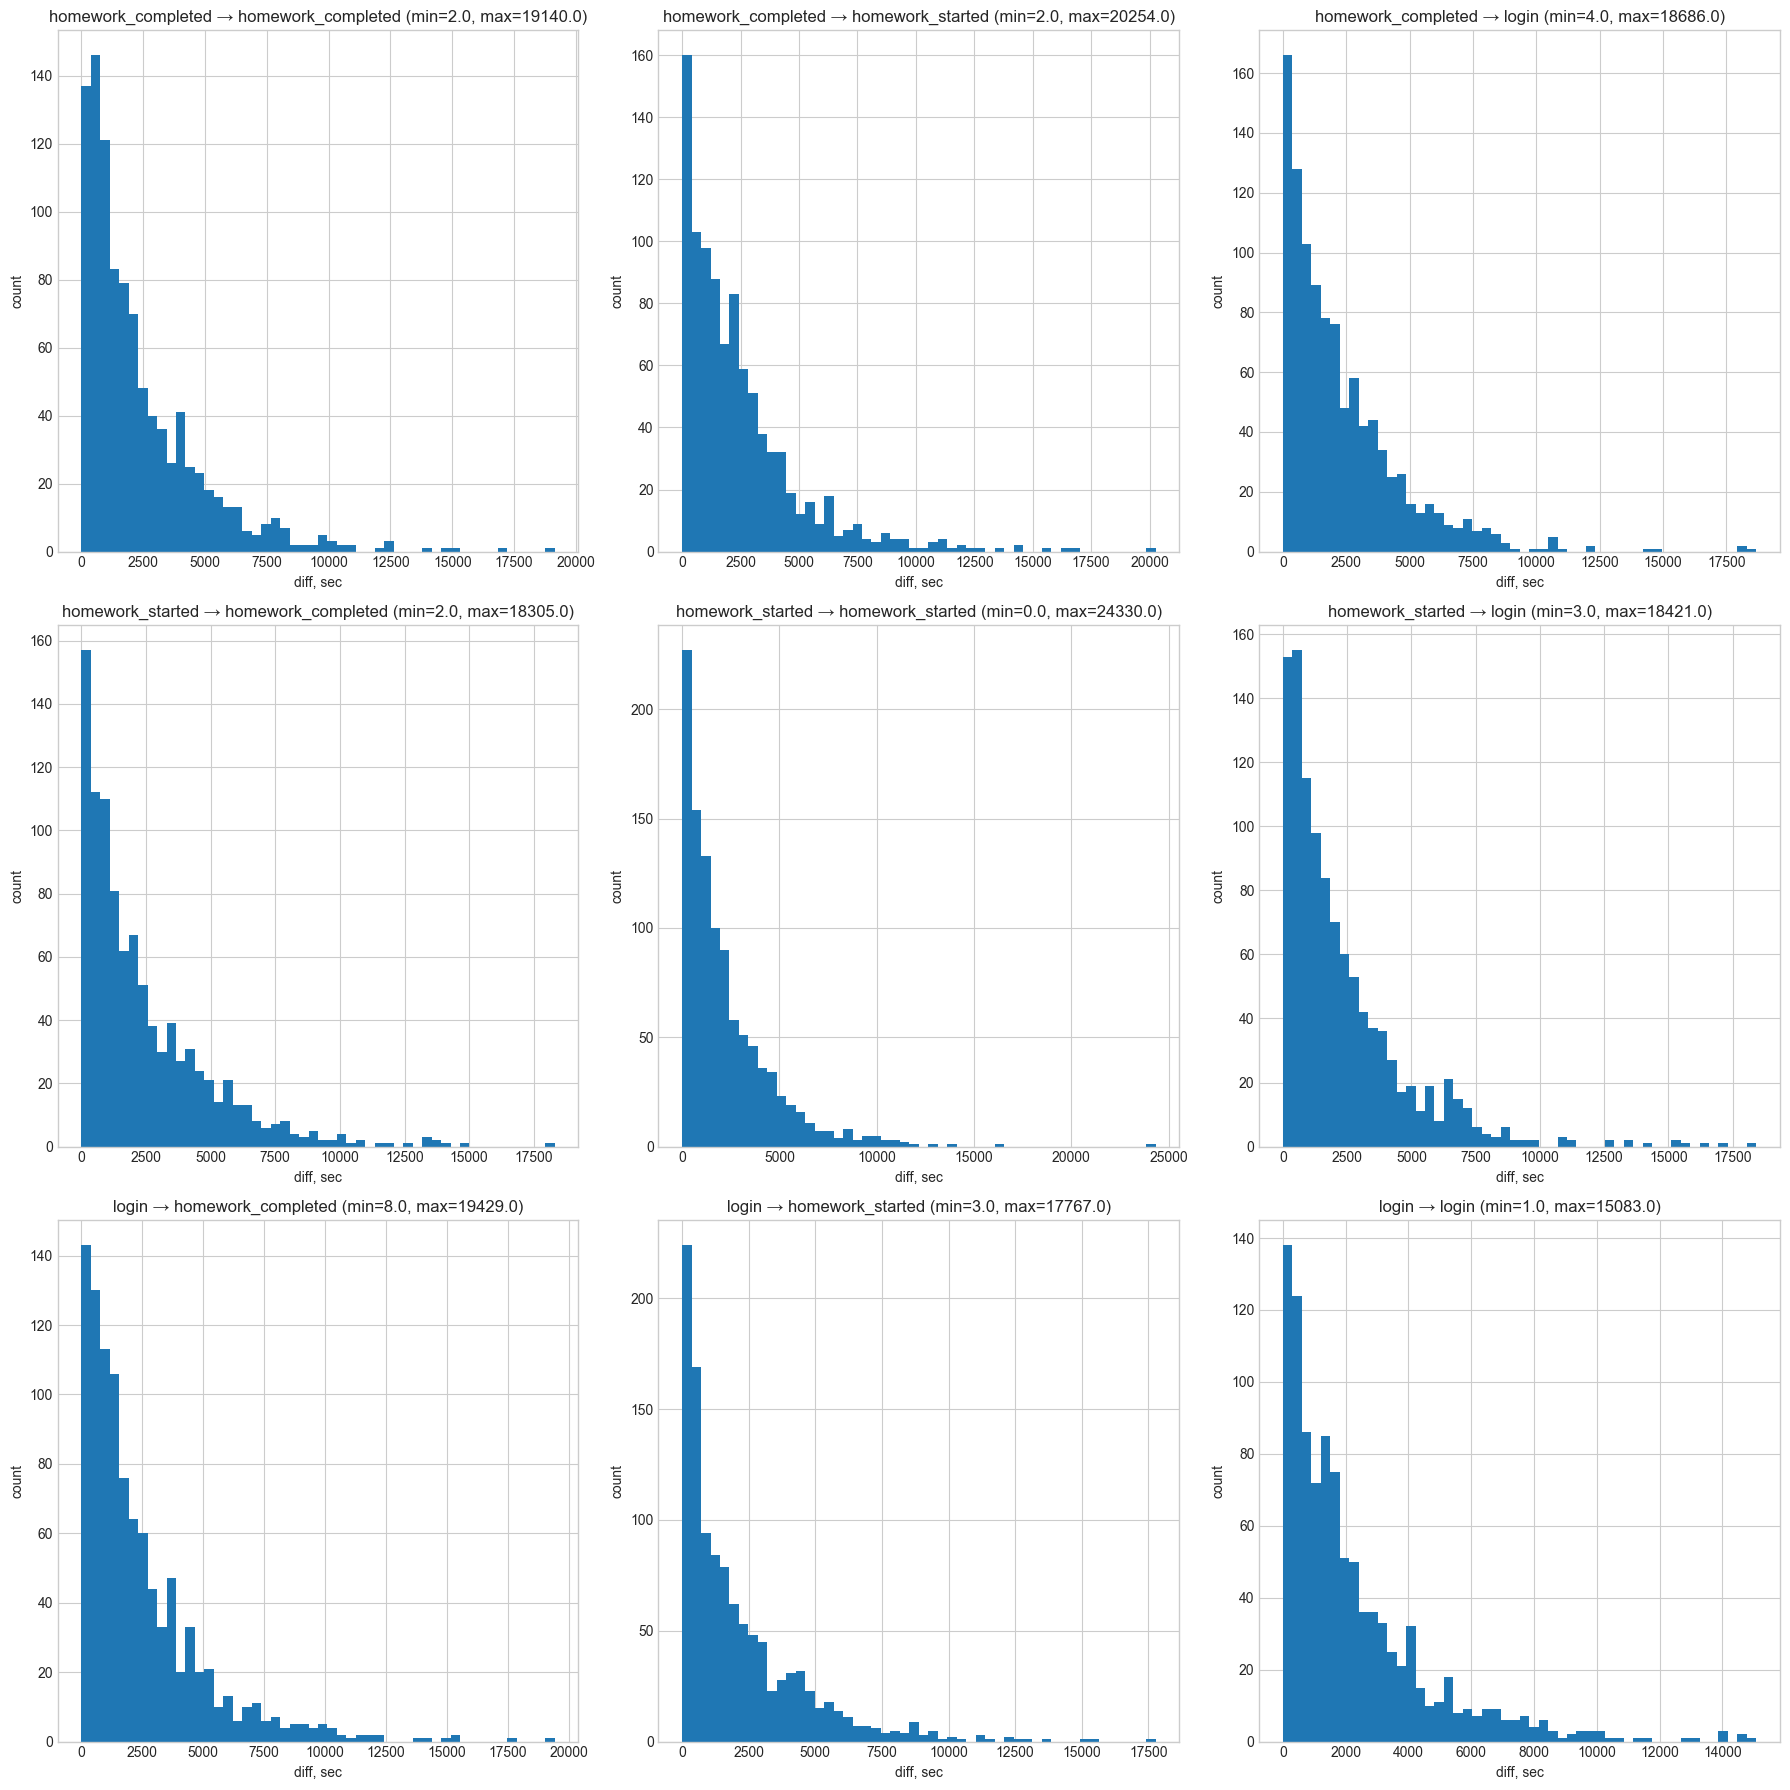

In [7]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_event_transition_matrix(df, exclude_events=None, n_bins=50, figsize=18):
    df = df.copy()

    if exclude_events:
        df = df[~df['event_type'].isin(exclude_events)]

    df = df.sort_values(['user_id', 'timestamp'])

    df['prev_event'] = df.groupby('user_id')['event_type'].shift()
    df['diff'] = df.groupby('user_id')['timestamp'].diff().dt.total_seconds()
    
    event_types = df['event_type'].unique()
    n = len(event_types)

    fig, axes = plt.subplots(n, n, figsize=(figsize, figsize))

    for i, from_event in enumerate(event_types):
        for j, to_event in enumerate(event_types):
            x = df[
                (df['prev_event'] == from_event) &
                (df['event_type'] == to_event)
            ]['diff'].dropna()
            
            axes[i, j].hist(x, bins=n_bins)
            axes[i, j].set_title(f'{from_event} → {to_event} (min={x.min()}, max={x.max()})')
            axes[i, j].set_xlabel('diff, sec')
            axes[i, j].set_ylabel('count')

    plt.tight_layout()
    plt.show()


plot_event_transition_matrix(
    df[df['user_id'].isin(bots)],
    exclude_events=['return_visit_d7', 'return_visit_d14'],
    n_bins=50,
)

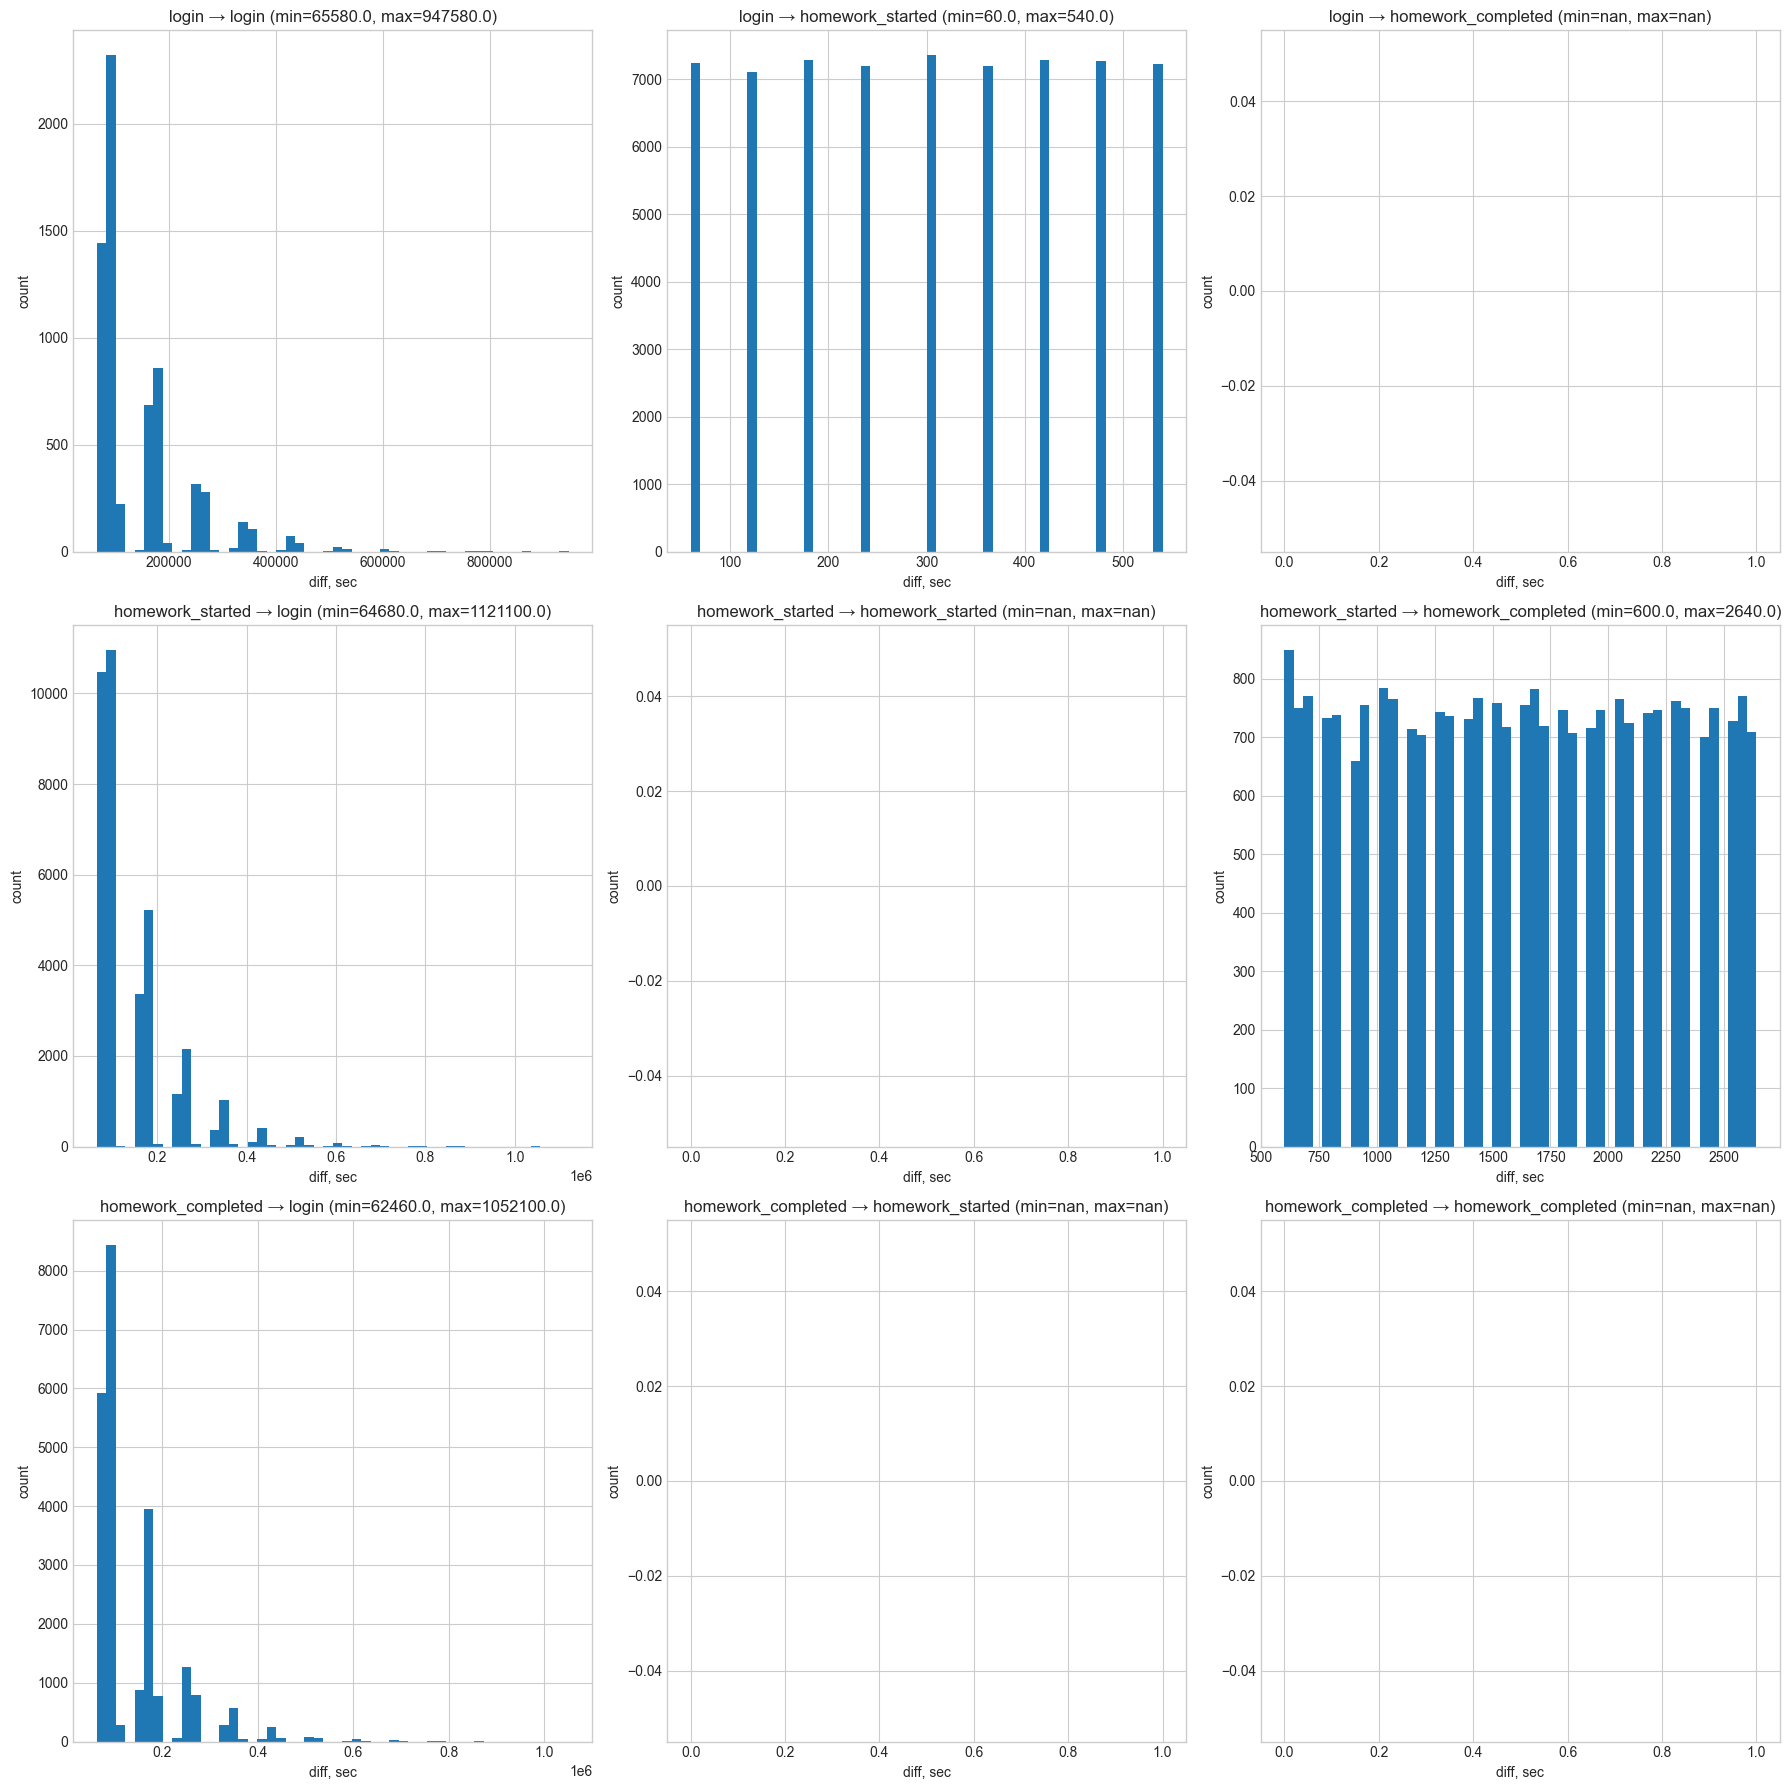

In [8]:
plot_event_transition_matrix(
    df_clean,
    exclude_events=['return_visit_d7', 'return_visit_d14'],
    n_bins=50,
)

In [9]:
# Видно что матрицы ботов и остальных юзеров отличаются критически. От подозрительных переходов между event, до идельно гладких распределений переходов

# df_clean данные кажутся сгенерированными, раз столь дискретны login -> homework_started
# Если датасет исходно сгенерированный - то нормально


=== diff ===
mean: 58448.5592
std:  88264.1766
skew: 2.2122
min: 0.0000
max: 1118820.0000

Quantiles:
0.0010       60.0000
0.0100       60.0000
0.0500      120.0000
0.1000      180.0000
0.2500      360.0000
0.3500      480.0000
0.5000     1860.0000
0.6000    72900.0000
0.7000    84300.0000
0.7500    88620.0000
0.8000    94020.0000
0.9500   252300.0000
0.9900   358440.0000
0.9990   604972.6800
Name: diff, dtype: float64


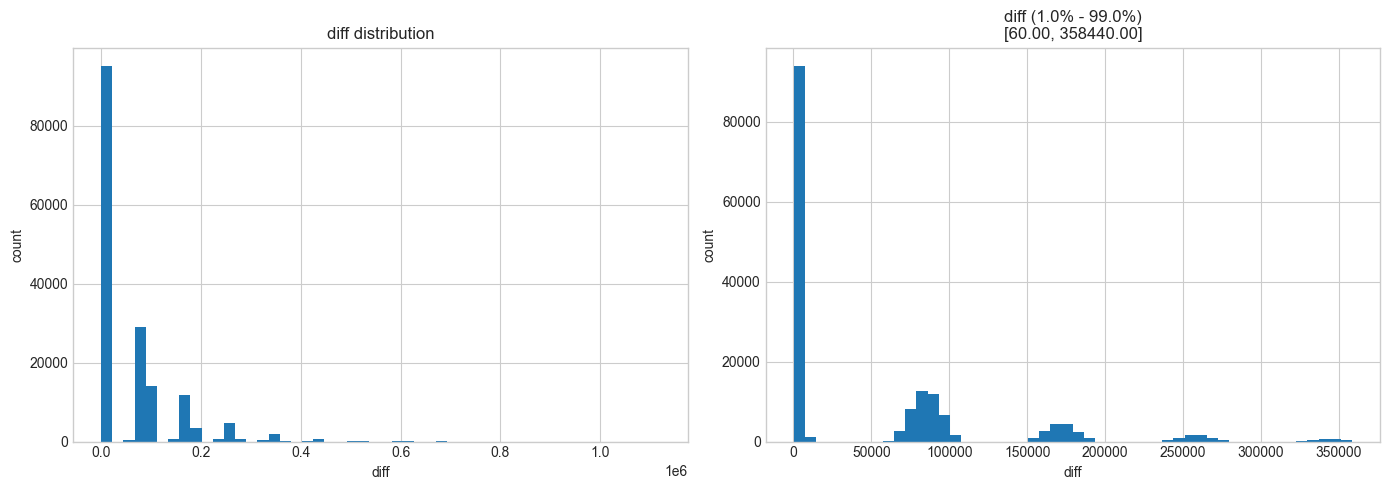

In [10]:
df_diff = df_clean.copy().sort_values(['user_id', 'timestamp'])
df_diff['diff'] = df_diff.groupby('user_id')['timestamp'].diff().dt.total_seconds()
df_diff = df_diff.dropna(subset=['diff'])
    
show_distribution(
    df_diff,
    'diff',
    quantiles=[
        0.001,
        0.01,
        0.05,
        0.10, 
        0.25,
        0.35,
        0.50,
        0.60,
        0.70,
        0.75,
        0.80,
        0.95,
        0.99,
        0.999,
    ],
    quantile_range=(0.01, 0.99)
)

In [11]:
# 0.5 -> 0.6 по квантилю
# вероятно переход от внутрисессионными и межсессионными интервалами
# 1860 сек ~ 31 мин.
# 72780 сек ~ 20.2 часа


=== grade ===
mean: 7.8258
std:  1.9845
skew: 0.1260
min: 5.0000
max: 11.0000

Quantiles:
Series([], Name: grade, dtype: float64)


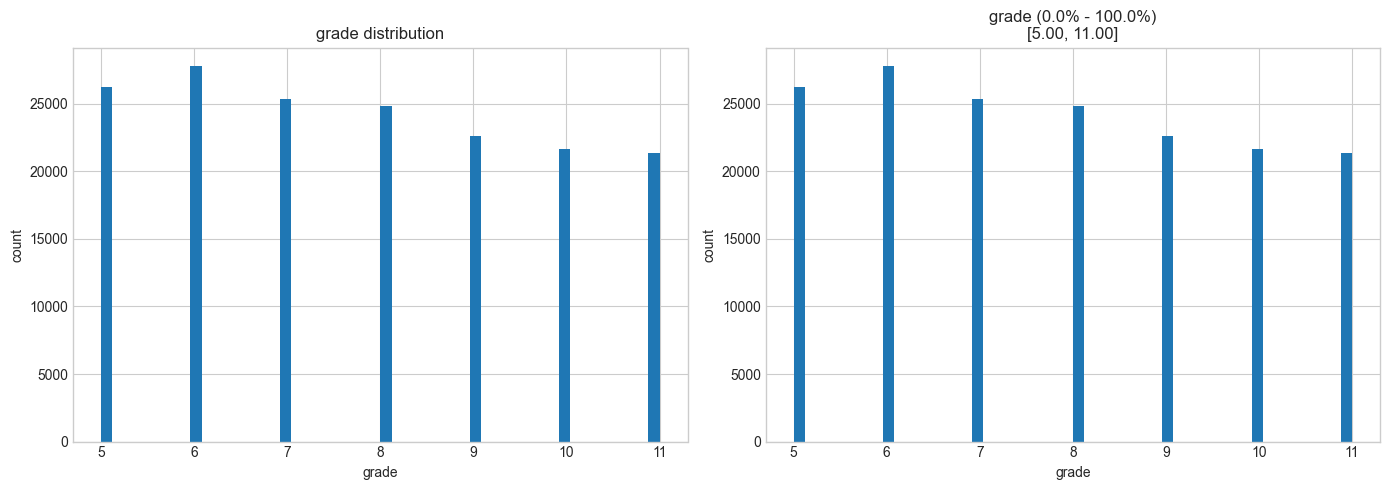

In [12]:
show_distribution(
    df_clean,
    'grade',
    quantiles=[],
    quantile_range=(0.0, 1.0)
)

## 2. Sanity Checks

### 2.1 Удаление пересечений между группами (Sample Contamination)

In [13]:
# Пользователи, попавшие в обе группы
# были удалены ещё на 1.1 как повторяющиеся в таблице df_groups пользователи
user_groups = df_clean.groupby('user_id')['group'].nunique()
overlap_users = user_groups[user_groups > 1].index

print('Пользователи в обеих группах:', overlap_users.tolist())
print('Количество:', len(overlap_users))

# Удаляем их
df_clean = df_clean[
    ~df_clean['user_id'].isin(overlap_users)
].copy()

print_ab_info(df_clean)

Пользователи в обеих группах: []
Количество: 0

Dataset Shape: (170050, 6)
Number Unique user_id: 5988
       n_rows  n_users  n_rows/n_users
group                                 
A       79190     2992         26.4672
B       90643     2988         30.3357



### 2.2 Sample Ratio Mismatch (SRM)

In [14]:
from scipy.stats import chisquare

counts = (
    df_clean
    .groupby('group')['user_id']
    .nunique()
    .sort_index()
)

print('Фактическое распределение:', counts.to_dict())

expected = [counts.sum() / 2] * 2

chi2, p_srm = chisquare(
    counts.values,
    expected
)

print(f'SRM χ² = {chi2:.4f}, p-value = {p_srm:.4f}')

Фактическое распределение: {'A': 2992, 'B': 2988}
SRM χ² = 0.0027, p-value = 0.9587


### 2.3 SRM по grade

In [15]:
user_grade_group = (
    df_clean[['user_id', 'grade', 'group']]
    .drop_duplicates('user_id')
)

grade_counts = pd.crosstab(
    user_grade_group['grade'],
    user_grade_group['group']
)

print(grade_counts.div(grade_counts.sum(axis=1), axis=0).round(3))

chi2_grade, p_grade, _, _ = stats.chi2_contingency(grade_counts)

print(f'\nSRM χ² по классам = {chi2_grade:.3f}, p-value = {p_grade:.3f}')

if p_grade > 0.05:
    print('✓ Распределение пользователей по классам и группам не показывает статистически значимого перекоса')
else:
    print('⚠ Обнаружен перекос распределения пользователей по классам — требуется исследование')

group        A      B
grade                
5.0000  0.5170 0.4830
6.0000  0.4910 0.5090
7.0000  0.4800 0.5200
8.0000  0.5130 0.4870
9.0000  0.5320 0.4680
10.0000 0.4830 0.5170
11.0000 0.4870 0.5130

SRM χ² по классам = 8.012, p-value = 0.237
✓ Распределение пользователей по классам и группам не показывает статистически значимого перекоса


In [16]:
# Проблем с пересечением и SRM не обнаружено. Лёгкий дисбаланс внутри классов 5-11 не критичен

## 3. Расчёт продуктовых метрик

In [17]:
def compute_product_metrics(df, thrs):
    user_metrics = (
        df.groupby(['user_id', 'group', 'grade'])
        .agg(
            logins=('event_type', lambda x: (x == 'login').sum()),
            homework_started=('event_type', lambda x: (x == 'homework_started').sum()),
            homework_completed=('event_type', lambda x: (x == 'homework_completed').sum()),
            active_days=('timestamp', lambda x: x.dt.date.nunique()),
            d7_return=('event_type', lambda x: (x == 'return_visit_d7').sum() > 0),
            d14_return=('event_type', lambda x: (x == 'return_visit_d14').sum() > 0),
        )
        .reset_index()
    )

    user_metrics['has_started'] = user_metrics['homework_started'] > 0
    user_metrics['has_completed'] = user_metrics['homework_completed'] > 0

    # Сколько ДЗ всего в курсе для данного класса: максимум внутри grade (обе группы вместе)
    # Предполагаем, что максимум среди количества начинаний или окончаний курса - и есть количество задач на курсе.
    user_metrics['total_hw'] = (
        user_metrics[['homework_started', 'homework_completed']].max(axis=1)
        .groupby(user_metrics['grade']).transform('max')
    )

    # Доля пройденных ДЗ от всех ДЗ курса
    user_metrics['completion_ratio'] = user_metrics['homework_completed'] / user_metrics['total_hw']
    for thr in thrs:
        user_metrics[f'completed_{int(thr*100)}pct'] = user_metrics['completion_ratio'] >= thr

    # Completion Rate из ТЗ: полное прохождение = завершил все ДЗ курса
    user_metrics['full_completion'] = user_metrics['homework_completed'] >= user_metrics['total_hw']

    first_started = (
        df[df['event_type'] == 'homework_started']
        .groupby('user_id')['timestamp']
        .min()
        .rename('first_started')
    )

    first_completed = (
        df[df['event_type'] == 'homework_completed']
        .groupby('user_id')['timestamp']
        .min()
        .rename('first_completed')
    )

    ttv = pd.concat([first_started, first_completed], axis=1).dropna()
    ttv['ttv_minutes'] = (ttv['first_completed'] - ttv['first_started']).dt.total_seconds() / 60

    user_metrics = user_metrics.merge(
        ttv[['ttv_minutes']],
        left_on='user_id',
        right_index=True,
        how='left'
    )
    return user_metrics

thrs=[0.25, 0.5, 0.75, 0.9]
user_metrics = compute_product_metrics(df_clean, thrs)
print('Пользователей в анализе:', user_metrics['user_id'].nunique())
print('Пользователей с рассчитанным TTV:', user_metrics['ttv_minutes'].notna().sum())
print("Доля юзеров которые выполнили все ДЗ:")
print(user_metrics.groupby('group')['full_completion'].mean())
print("Среднее значение доли выполненных ДЗ:")
print(user_metrics.groupby('group')['completion_ratio'].mean())
print("Доля пользователей с пройденным порогом выполненных ДЗ:")
print(user_metrics.groupby('group')[[f'completed_{int(x*100)}pct' for x in thrs]].mean())
user_metrics.head()

Пользователей в анализе: 5980
Пользователей с рассчитанным TTV: 5874
Доля юзеров которые выполнили все ДЗ:
group
A   0.0000
B   0.0000
Name: full_completion, dtype: float64
Среднее значение доли выполненных ДЗ:
group
A   0.1991
B   0.2818
Name: completion_ratio, dtype: float64
Доля пользователей с пройденным порогом выполненных ДЗ:
       completed_25pct  completed_50pct  completed_75pct  completed_90pct
group                                                                    
A               0.3118           0.0067           0.0000           0.0000
B               0.5867           0.0843           0.0007           0.0000


,user_id,group,grade,logins,homework_started,homework_completed,active_days,d7_return,d14_return,has_started,has_completed,total_hw,completion_ratio,completed_25pct,completed_50pct,completed_75pct,completed_90pct,full_completion,ttv_minutes
0,U300000,B,5.0000,14,11,6,15,True,True,True,True,19,0.3158,True,False,False,False,False,5732.0000
1,U300001,B,9.0000,14,11,3,15,True,True,True,True,18,0.1667,False,False,False,False,False,10170.0000
2,U300002,B,9.0000,12,11,4,13,True,True,True,True,18,0.2222,False,False,False,False,False,5821.0000
3,U300003,A,5.0000,10,10,3,11,True,True,True,True,19,0.1579,False,False,False,False,False,7046.0000
4,U300004,B,11.0000,13,12,3,14,True,False,True,True,16,0.1875,False,False,False,False,False,43.0000


### 3.1. Воронка конверсии

In [18]:
thr_cols = [f'completed_{round(x*100)}pct' for x in thrs]

funnel = user_metrics.groupby('group').agg(
    users=('user_id', 'count'),
    logged_in=('logins', lambda x: (x > 0).sum()),
    started=('has_started', 'sum'),
    completed_1hw=('has_completed', 'sum'),
    **{c: (c, 'sum') for c in thr_cols}
)

steps = ['users', 'logged_in', 'started', 'completed_1hw'] + thr_cols

# конверсия относительно предыдущего шага и от всех пользователей
for prev, cur in zip(steps[:-1], steps[1:]):
    funnel[f'{cur}__step'] = funnel[cur] / funnel[prev]
for s in steps[1:]:
    funnel[f'{s}__of_users'] = funnel[s] / funnel['users']

funnel.T

group,A,B
users,2992.0000,2988.0000
logged_in,2992.0000,2988.0000
started,2992.0000,2988.0000
completed_1hw,2921.0000,2953.0000
completed_25pct,933.0000,1753.0000
completed_50pct,20.0000,252.0000
completed_75pct,0.0000,2.0000
completed_90pct,0.0000,0.0000
logged_in__step,1.0000,1.0000
started__step,1.0000,1.0000


### 3.2. Ключевые метрики по группам

In [19]:
summary = user_metrics.groupby('group').agg(
    n=('user_id', 'count'),
    n_ttv=('ttv_minutes', 'count'),
    d7_retention=('d7_return', 'mean'),
    d14_retention=('d14_return', 'mean'),
    active_days=('active_days', 'mean'),
    completion_ratio=('completion_ratio', 'mean'),
    median_completion_ratio=('completion_ratio', 'median'),
    completed_25pct=('completed_25pct', 'mean'),
    completed_50pct=('completed_50pct', 'mean'),
    has_completed_1hw=('has_completed', 'mean'),
    avg_hw_completed=('homework_completed', 'mean'),
    avg_hw_started=('homework_started', 'mean'),
    median_hw_completed=('homework_completed', 'median'),
    avg_ttv_minutes=('ttv_minutes', 'mean'),
    median_ttv_minutes=('ttv_minutes', 'median'),
).T
summary

group,A,B
n,2992.0000,2988.0000
n_ttv,2921.0000,2953.0000
d7_retention,0.7269,0.7798
d14_retention,0.2881,0.3624
active_days,11.9616,13.1262
completion_ratio,0.1991,0.2818
median_completion_ratio,0.1875,0.2778
completed_25pct,0.3118,0.5867
completed_50pct,0.0067,0.0843
has_completed_1hw,0.9763,0.9883


## 4. Сегментация по классам (grade)

### 4.1 Сегментация по классам

In [20]:
def pivot_metric(metric, aggfunc='mean'):
    p = user_metrics.pivot_table(index='grade', columns='group', values=metric, aggfunc=aggfunc)
    p['diff'] = p['B'] - p['A']
    p['rel_lift_%'] = (p['diff'] / p['A'].replace(0, np.nan) * 100).round(1)
    return p

print('=== D7 Retention ===')
display(pivot_metric('d7_return').round(4))

print('\n=== D14 Retention ===')
display(pivot_metric('d14_return').round(4))

print('\n=== Completion Ratio (доля пройденного курса) ===')
display(pivot_metric('completion_ratio').round(4))

print('\n=== Completed >= 25% курса ===')
display(pivot_metric('completed_25pct').round(4))

print('\n=== Completed >= 50% курса ===')
display(pivot_metric('completed_50pct').round(4))

print('\n=== Avg Homework Completed ===')
display(pivot_metric('homework_completed').round(2))

print('\n=== Median Time to Value (minutes) ===')
display(pivot_metric('ttv_minutes', aggfunc='median').round(1))

=== D7 Retention ===


group,A,B,diff,rel_lift_%
grade,,,,
5.0000,0.7287,0.8245,0.0958,13.1000
6.0000,0.7556,0.8658,0.1102,14.6000
7.0000,0.7065,0.8460,0.1395,19.7000
8.0000,0.7357,0.7749,0.0393,5.3000
9.0000,0.7163,0.7836,0.0674,9.4000
10.0000,0.7139,0.6986,-0.0153,-2.1000
11.0000,0.7284,0.6604,-0.0680,-9.3000



=== D14 Retention ===


group,A,B,diff,rel_lift_%
grade,,,,
5.0000,0.2848,0.4351,0.1503,52.8000
6.0000,0.3004,0.4589,0.1584,52.7000
7.0000,0.2612,0.4391,0.1779,68.1000
8.0000,0.2885,0.3457,0.0572,19.8000
9.0000,0.2930,0.3456,0.0526,18.0000
10.0000,0.3154,0.2603,-0.0551,-17.5000
11.0000,0.2716,0.2459,-0.0257,-9.5000



=== Completion Ratio (доля пройденного курса) ===


...

group,A,B,diff,rel_lift_%
grade,,,,
5.0000,0.0022,0.1202,0.1180,5260.6000
6.0000,0.0022,0.2229,0.2207,9843.3000
7.0000,0.0050,0.1632,0.1582,3180.7000
8.0000,0.0022,0.0139,0.0117,532.0000
9.0000,0.0093,0.0422,0.0329,353.8000
10.0000,0.0098,0.0023,-0.0075,-76.7000
11.0000,0.0173,0.0117,-0.0056,-32.3000



=== Avg Homework Completed ===


group,A,B,diff,rel_lift_%
grade,,,,
5.0000,3.6300,6.8800,3.2500,89.4000
6.0000,3.4900,6.7400,3.2500,93.3000
7.0000,3.6700,6.3600,2.6900,73.4000
8.0000,3.5300,4.8500,1.3200,37.4000
9.0000,3.5200,4.9100,1.4000,39.7000
10.0000,3.6500,2.9900,-0.6600,-18.0000
11.0000,3.5900,2.9300,-0.6600,-18.3000



=== Median Time to Value (minutes) ===


group,A,B,diff,rel_lift_%
grade,,,,
5.0000,2858.0000,41.0000,-2817.0000,-98.6000
6.0000,2802.5000,40.0000,-2762.5000,-98.6000
7.0000,2929.0000,43.0000,-2886.0000,-98.5000
8.0000,1703.0000,1463.0000,-240.0000,-14.1000
9.0000,4108.0000,1412.0000,-2696.0000,-65.6000
10.0000,2756.0000,4038.0000,1282.0000,46.5000
11.0000,3006.5000,4029.0000,1022.5000,34.0000


### 4.2 Графики распределений метрик

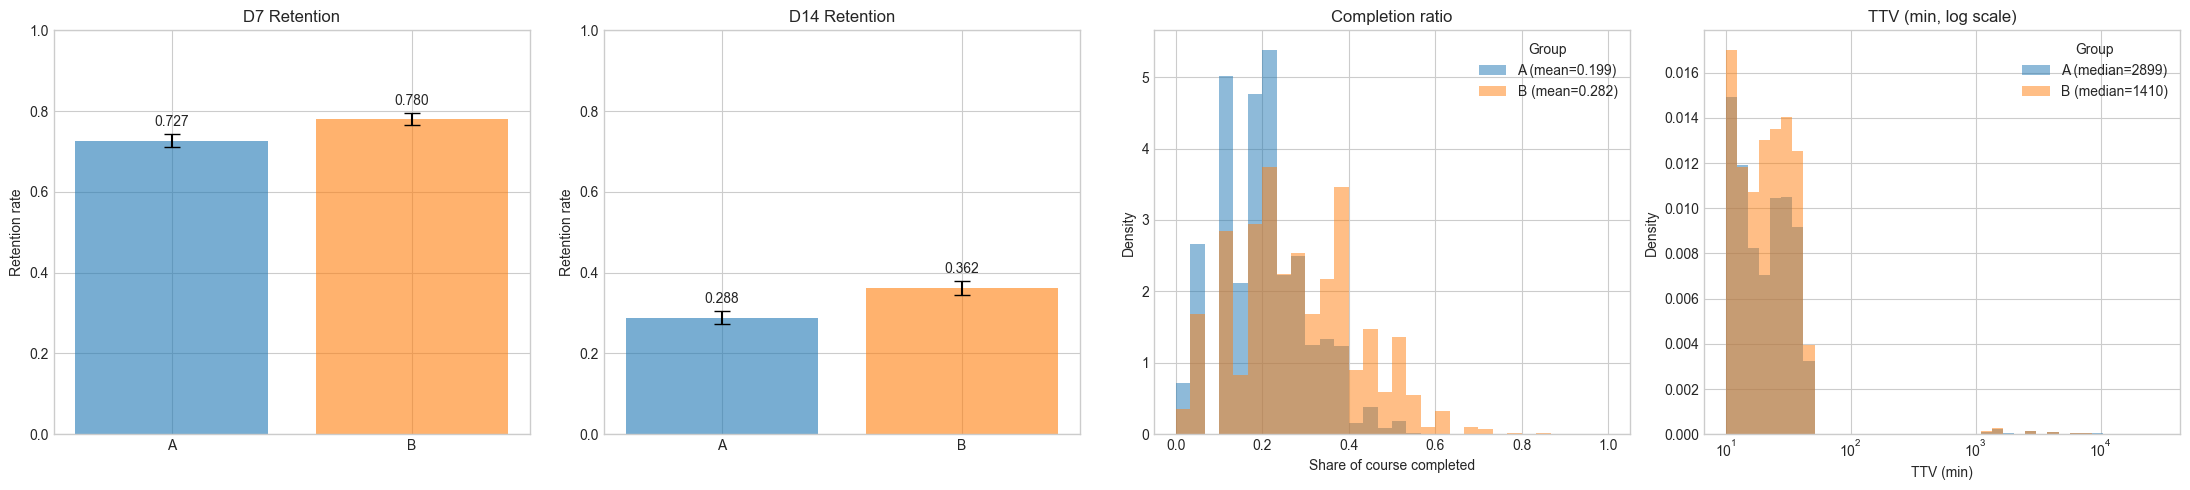

In [21]:
from statsmodels.stats.proportion import proportion_confint

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
colors = {'A': 'tab:blue', 'B': 'tab:orange'}

# -------------------------
# D7 / D14 Retention с 95% CI (Wilson)
# -------------------------
for ax, col, title in [(axes[0], 'd7_return', 'D7 Retention'),
                       (axes[1], 'd14_return', 'D14 Retention')]:
    for group in ['A', 'B']:
        values = user_metrics.loc[user_metrics['group'] == group, col].dropna()
        k, n = values.sum(), len(values)
        lo, hi = proportion_confint(k, n, method='wilson')
        ax.bar([group], [values.mean()], alpha=0.6, color=colors[group],
               yerr=[[values.mean() - lo], [hi - values.mean()]], capsize=6)
        ax.text(group, hi + 0.02, f'{values.mean():.3f}', ha='center')
    ax.set_title(title)
    ax.set_ylabel('Retention rate')
    ax.set_ylim(0, 1)

# -------------------------
# Completion ratio (доля пройденного курса)
# -------------------------
bins = np.linspace(0, 1, 31)
for group in ['A', 'B']:
    values = user_metrics.loc[user_metrics['group'] == group, 'completion_ratio'].dropna()
    axes[2].hist(values, bins=bins, alpha=0.5, density=True,
                 color=colors[group], label=f'{group} (mean={values.mean():.3f})')

axes[2].set_title('Completion ratio')
axes[2].set_xlabel('Share of course completed')
axes[2].set_ylabel('Density')
axes[2].legend(title='Group')

# -------------------------
# TTV (лог-шкала: распределение сильно скошено)
# -------------------------
ttv_pos = user_metrics['ttv_minutes'].dropna()
ttv_pos = ttv_pos[ttv_pos > 0]
bins_ttv = np.logspace(np.log10(ttv_pos.min()), np.log10(ttv_pos.max()), 40)
for group in ['A', 'B']:
    values = user_metrics.loc[user_metrics['group'] == group, 'ttv_minutes'].dropna()
    values = values[values > 0]
    axes[3].hist(values, bins=bins_ttv, alpha=0.5, density=True,
                 color=colors[group], label=f'{group} (median={values.median():.0f})')

axes[3].set_xscale('log')
axes[3].set_title('TTV (min, log scale)')
axes[3].set_xlabel('TTV (min)')
axes[3].set_ylabel('Density')
axes[3].legend(title='Group')

plt.tight_layout()
plt.show()

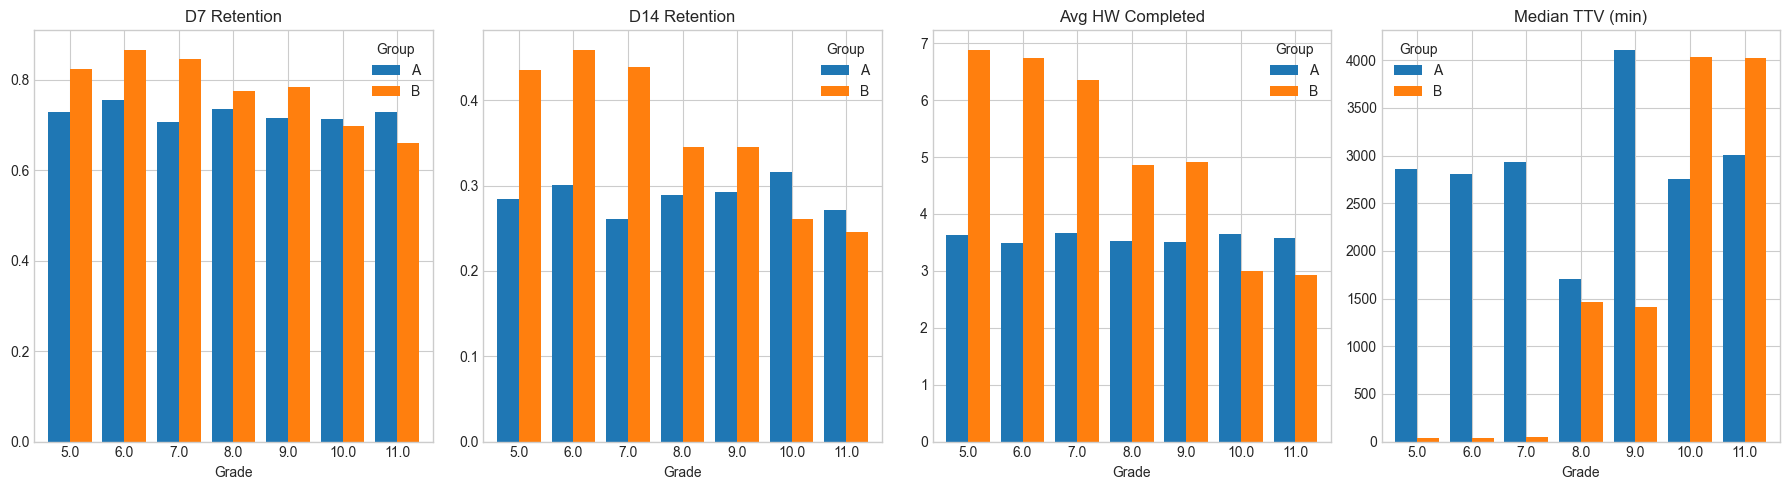

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric, title, agg in zip(
    axes,
    ['d7_return', 'd14_return', 'homework_completed', 'ttv_minutes'],
    ['D7 Retention', 'D14 Retention', 'Avg HW Completed', 'Median TTV (min)'],
    ['mean', 'mean', 'mean', 'median']
):
    p = pivot_metric(metric, aggfunc=agg)
    p[['A', 'B']].plot(kind='bar', ax=ax, width=0.8)
    ax.set_title(title)
    ax.set_xlabel('Grade')
    ax.legend(title='Group')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('metrics_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

**Наблюдение:** эффект геймификации сильно зависит от возраста:
- **5–7 классы** — выраженный положительный эффект
- **8-9 классы** - положительный эффект
- **10–11 классы** — нейтральный / отрицательный эффект

## 5. Статистическое тестирование

In [23]:
from scipy.stats import fisher_exact
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
from statsmodels.stats.multitest import multipletests

def proportion_test(df, metric, group_col='group'):
    """Z-тест (Фишер при малых счётчиках) + 95% CI разницы (Newcombe)"""
    a = df[df[group_col] == 'A'][metric].astype(float)
    b = df[df[group_col] == 'B'][metric].astype(float)
    xa, xb, na, nb = int(a.sum()), int(b.sum()), len(a), len(b)

    _, p_z = proportions_ztest([xb, xa], [nb, na])
    _, p_f = fisher_exact([[xb, nb - xb], [xa, na - xa]])
    small = min(xa, xb, na - xa, nb - xb) < 10          # мало событий -> доверяем Фишеру
    p_value = p_f if small else p_z

    lo, hi = confint_proportions_2indep(xb, nb, xa, na, method='newcomb')
    pa, pb = xa / na, xb / nb

    return {
        'metric': metric, 'A_rate': pa, 'B_rate': pb, 'diff': pb - pa,
        'rel_lift_%': (pb - pa) / pa * 100 if pa > 0 else np.nan,
        'p_value': p_value, 'test': 'fisher' if small else 'z',
        'ci_low': lo, 'ci_high': hi, 'n_A': na, 'n_B': nb,
    }

metrics = ['d7_return', 'd14_return', 'completed_25pct', 'completed_50pct']
results_df = pd.DataFrame([proportion_test(user_metrics, m) for m in metrics])
results_df['p_holm'] = multipletests(results_df['p_value'], method='holm')[1]
results_df.round(4)

,metric,A_rate,B_rate,diff,rel_lift_%,p_value,test,ci_low,ci_high,n_A,n_B,p_holm
0,d7_return,0.7269,0.7798,0.0528,7.2698,0.0000,z,0.0310,0.0746,2992,2988,0.0000
1,d14_return,0.2881,0.3624,0.0743,25.8062,0.0000,z,0.0506,0.0980,2992,2988,0.0000
2,completed_25pct,0.3118,0.5867,0.2748,88.1401,0.0000,z,0.2504,0.2988,2992,2988,0.0000
3,completed_50pct,0.0067,0.0843,0.0777,1161.6867,0.0000,z,0.0675,0.0884,2992,2988,0.0000


In [24]:
def bootstrap_ci(b_values, a_values, stat=np.mean, ci_percentile=[2.5, 97.5], n_boot=10000, seed=42):
    rng = np.random.default_rng(seed)
    b_idx = rng.integers(0, len(b_values), size=(n_boot, len(b_values)))
    a_idx = rng.integers(0, len(a_values), size=(n_boot, len(a_values)))
    diffs = stat(b_values[b_idx], axis=1) - stat(a_values[a_idx], axis=1)
    return np.percentile(diffs, ci_percentile)

# метрика -> статистика, по которой строим разницу и CI
cont_metrics = {
    'completion_ratio': np.mean,
    'homework_completed': np.mean,
    'ttv_minutes': np.median,   # скошенное распределение, только среди завершивших ДЗ
}

for metric, stat in cont_metrics.items():
    a = user_metrics.loc[user_metrics['group'] == 'A', metric].dropna().values
    b = user_metrics.loc[user_metrics['group'] == 'B', metric].dropna().values
    ci_low, ci_high = bootstrap_ci(b, a, stat=stat)
    u_stat, p_mwu = stats.mannwhitneyu(b, a, alternative='two-sided')
    name = 'mean' if stat is np.mean else 'median'
    print(f'{metric}:')
    print(f'  n A = {len(a)}, n B = {len(b)}')
    print(f'  {name} A = {stat(a):.4f}, {name} B = {stat(b):.4f}')
    print(f'  Mann-Whitney p = {p_mwu:.2e}')
    print(f'  Разница ({name}) = {stat(b) - stat(a):.4f}, '
          f'95% bootstrap CI = [{ci_low:.4f}; {ci_high:.4f}]\n')

completion_ratio:
  n A = 2992, n B = 2988
  mean A = 0.1991, mean B = 0.2818
  Mann-Whitney p = 3.36e-131
  Разница (mean) = 0.0826, 95% bootstrap CI = [0.0765; 0.0886]

homework_completed:
  n A = 2992, n B = 2988
  mean A = 3.5802, mean B = 5.1068
  Mann-Whitney p = 3.61e-127
  Разница (mean) = 1.5265, 95% bootstrap CI = [1.4138; 1.6359]

ttv_minutes:
  n A = 2921, n B = 2953
  median A = 2899.0000, median B = 1410.0000
  Mann-Whitney p = 1.50e-23
  Разница (median) = -1489.0000, 95% bootstrap CI = [-1600.0000; -1370.0000]



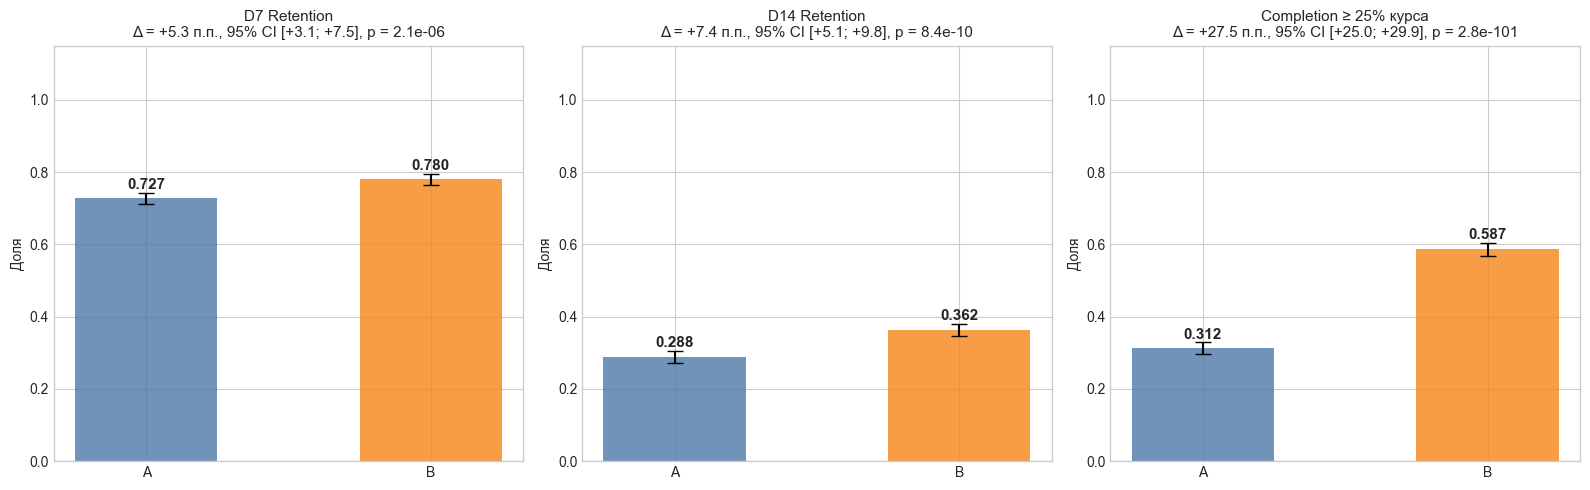

In [25]:
from statsmodels.stats.proportion import proportion_confint

metrics = ['d7_return', 'd14_return', 'completed_25pct']
titles  = ['D7 Retention', 'D14 Retention', 'Completion ≥ 25% курса']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, metric, title in zip(axes, metrics, titles):
    for group, color in zip(['A', 'B'], ['#4C78A8', '#F58518']):
        x = user_metrics.loc[user_metrics['group'] == group, metric].astype(int)
        k, n = x.sum(), len(x)
        p = k / n
        lo, hi = proportion_confint(k, n, method='wilson')
        ax.bar(group, p, color=color, alpha=0.8, width=0.5,
               yerr=[[p - lo], [hi - p]], capsize=6,
               error_kw=dict(lw=1.5, ecolor='black'))
        ax.text(group, hi + 0.01, f'{p:.3f}', ha='center', fontsize=11, fontweight='bold')

    # разница B - A (в п.п.) с 95% CI (Newcombe) и p-value
    r = results_df[results_df['metric'] == metric].iloc[0]
    ax.set_title(f'{title}\n'
                 f'Δ = {r["diff"]*100:+.1f} п.п., '
                 f'95% CI [{r["ci_low"]*100:+.1f}; {r["ci_high"]*100:+.1f}], '
                 f'p = {r["p_value"]:.1e}', fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Доля')

plt.tight_layout()
plt.savefig('retention_with_ci.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.1. Тесты по сегментам

In [26]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

segments = {
    'grades 5-7':  user_metrics['grade'].between(5, 7),
    'grades 8-9':  user_metrics['grade'].between(8, 9),
    'grades 10-11': user_metrics['grade'].between(10, 11),
}
metrics = ['d7_return', 'd14_return', 'completed_25pct', 'completed_50pct']

rows = []
for name, mask in segments.items():
    seg = user_metrics[mask]
    for m in metrics:
        r = proportion_test(seg, m)
        r['segment'] = name
        rows.append(r)
seg_df = pd.DataFrame(rows)
seg_df['p_holm'] = multipletests(seg_df['p_value'], method='holm')[1]

display(seg_df[['segment', 'metric', 'A_rate', 'B_rate', 'diff', 'ci_low', 'ci_high', 'p_value', 'p_holm', 'test']]
        .style.format({'p_value': '{:.2e}', 'p_holm': '{:.2e}'}))

# Формальная проверка: зависит ли эффект от класса (взаимодействие group × grade)
um = user_metrics.assign(is_B=(user_metrics.group == 'B').astype(int),
                         d7=user_metrics.d7_return.astype(int),
                         d14=user_metrics.d14_return.astype(int))
for y in ['d7', 'd14']:
    full = smf.logit(f'{y} ~ is_B * C(grade)', um).fit(disp=0)
    red = smf.logit(f'{y} ~ is_B + C(grade)', um).fit(disp=0)
    lr = 2 * (full.llf - red.llf)
    df_diff = full.df_model - red.df_model
    from scipy.stats import chi2
    print(f'{y}: interaction LR p = {chi2.sf(lr, df_diff):.2e}')

full = smf.ols('completion_ratio ~ is_B * C(grade)', um).fit()
red = smf.ols('completion_ratio ~ is_B + C(grade)', um).fit()
print(sm.stats.anova_lm(red, full))

,segment,metric,A_rate,B_rate,diff,ci_low,ci_high,p_value,p_holm,test
0,grades 5-7,d7_return,0.731066,0.846154,0.115087,0.083926,0.146043,5.97e-13,4.78e-12,z
1,grades 5-7,d14_return,0.282844,0.444783,0.161939,0.125271,0.197978,8.69e-18,7.82e-17,z
2,grades 5-7,completed_25pct,0.282071,0.830160,0.548089,0.515163,0.578792,1.19e-174,1.42e-173,z
3,grades 5-7,completed_50pct,0.003091,0.170602,0.167510,0.147539,0.188894,6.08e-65,6.69e-64,fisher
4,grades 8-9,d7_return,0.726244,0.779012,0.052768,0.011587,0.093517,1.21e-02,6.03e-02,z
5,grades 8-9,d14_return,0.290724,0.345679,0.054955,0.010581,0.099182,1.52e-02,6.07e-02,z
6,grades 8-9,completed_25pct,0.263575,0.548148,0.284573,0.238901,0.328576,6.94e-33,6.94e-32,z
7,grades 8-9,completed_50pct,0.005656,0.027160,0.021504,0.009658,0.035504,3.67e-04,2.20e-03,fisher
8,grades 10-11,d7_return,0.721130,0.679769,-0.041361,-0.084904,0.002514,6.46e-02,1.89e-01,z
9,grades 10-11,d14_return,0.293612,0.253179,-0.040433,-0.082998,0.002194,6.30e-02,1.89e-01,z


d7: interaction LR p = 1.99e-07
d14: interaction LR p = 2.76e-08
   df_resid     ssr  df_diff  ss_diff        F  Pr(>F)
0 5972.0000 76.8629   0.0000      NaN      NaN     NaN
1 5966.0000 65.8367   6.0000  11.0262 166.5291  0.0000


## 6. Мощность и MDE

In [27]:
from scipy.stats import norm
from scipy.optimize import brentq

def calculate_mde(baseline, n1, n2, alpha=0.05, power_target=0.9):
    z_alpha = norm.ppf(1 - alpha / 2)
    def power_for_delta(delta):
        p2 = baseline + delta
        se_alt = np.sqrt(baseline*(1-baseline)/n1 + p2*(1-p2)/n2)
        effect = delta / se_alt
        power = norm.cdf(-z_alpha - effect) + (1 - norm.cdf(z_alpha - effect))
        return power
    return brentq(lambda d: power_for_delta(d) - power_target, 1e-10, 1 - baseline - 1e-10)

n_a = (user_metrics['group'] == 'A').sum()
n_b = (user_metrics['group'] == 'B').sum()

metrics_mde = {
    'D7 Retention': user_metrics[user_metrics['group']=='A']['d7_return'].mean(),
    'D14 Retention': user_metrics[user_metrics['group']=='A']['d14_return'].mean(),
    'Completion Rate': user_metrics[user_metrics['group']=='A']['completed_25pct'].mean(),
}
alpha=0.05
power_target=0.9
print(f'Размеры выборок: A={n_a}, B={n_b}\n')
print(f"Power={power_target}, alpha={alpha}")
for name, baseline in metrics_mde.items():
    mde = calculate_mde(baseline, n_a, n_b, alpha, power_target)
    print(f'{name}: baseline={baseline:.4f}, MDE={mde:.4f} ({mde*100:.2f} p.p.)')


Размеры выборок: A=2992, B=2988

Power=0.9, alpha=0.05
D7 Retention: baseline=0.7269, MDE=0.0365 (3.65 p.p.)
D14 Retention: baseline=0.2881, MDE=0.0387 (3.87 p.p.)
Completion Rate: baseline=0.3118, MDE=0.0394 (3.94 p.p.)


In [28]:
rows = []
for name, mask in segments.items():
    seg = user_metrics[mask]
    n_a_s = (seg['group'] == 'A').sum()
    n_b_s = (seg['group'] == 'B').sum()
    for label, col in [('D7 Retention', 'd7_return'),
                       ('D14 Retention', 'd14_return'),
                       ('Completion ≥25%', 'completed_25pct')]:
        base = seg.loc[seg['group'] == 'A', col].mean()
        mde = calculate_mde(base, n_a_s, n_b_s, alpha, power_target)
        observed = seg.loc[seg['group'] == 'B', col].mean() - base
        rows.append((name, label, n_a_s, n_b_s, base, mde * 100, observed * 100))

mde_seg = pd.DataFrame(rows, columns=['segment', 'metric', 'n_A', 'n_B',
                                      'baseline', 'MDE_pp', 'observed_diff_pp'])
display(mde_seg.round(2))

,segment,metric,n_A,n_B,baseline,MDE_pp,observed_diff_pp
0,grades 5-7,D7 Retention,1294,1313,0.7300,5.4300,11.5100
1,grades 5-7,D14 Retention,1294,1313,0.2800,5.8700,16.1900
2,grades 5-7,Completion ≥25%,1294,1313,0.2800,5.8700,54.8100
3,grades 8-9,D7 Retention,884,810,0.7300,6.7000,5.2800
4,grades 8-9,D14 Retention,884,810,0.2900,7.3900,5.5000
5,grades 8-9,Completion ≥25%,884,810,0.2600,7.2100,28.4600
6,grades 10-11,D7 Retention,814,865,0.7200,6.8000,-4.1400
7,grades 10-11,D14 Retention,814,865,0.2900,7.4200,-4.0400
8,grades 10-11,Completion ≥25%,814,865,0.4100,7.8500,-15.8400


In [29]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

for name, base in [('D7', 0.72), ('D14', 0.29)]:
    h = proportion_effectsize(base + 0.04, base)
    n = NormalIndPower().solve_power(effect_size=h, alpha=0.05, power=0.9, ratio=1)
    print(f'{name}: нужно ~{int(np.ceil(n))} на группу для эффекта 4 п.п.')

D7: нужно ~2524 на группу для эффекта 4 п.п.
D14: нужно ~2807 на группу для эффекта 4 п.п.


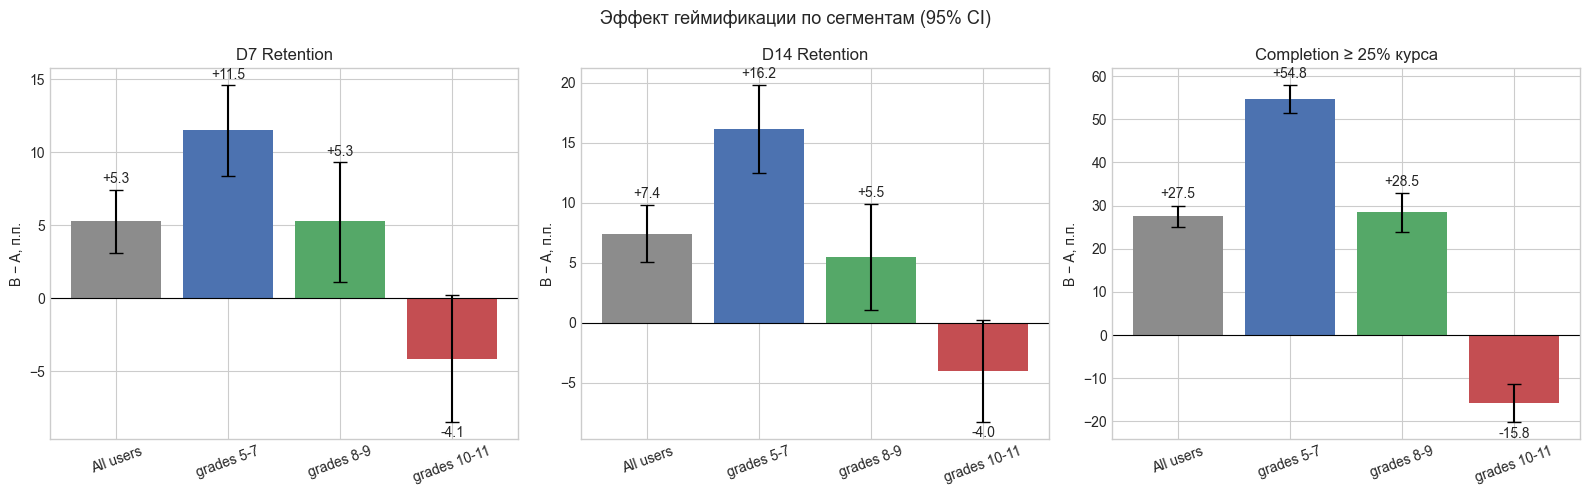

In [30]:
# Все пользователи + три сегмента в одной таблице
plot_df = pd.concat([
    results_df.assign(segment='All users'),
    seg_df
], ignore_index=True)

seg_order = ['All users', 'grades 5-7', 'grades 8-9', 'grades 10-11']
metrics_plot = [('d7_return', 'D7 Retention'),
                ('d14_return', 'D14 Retention'),
                ('completed_25pct', 'Completion ≥ 25% курса')]
colors = ['#8C8C8C', '#4C72B0', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (metric, title) in zip(axes, metrics_plot):
    sub = plot_df[plot_df['metric'] == metric].set_index('segment').loc[seg_order]
    diff = sub['diff'] * 100
    lo = diff - sub['ci_low'] * 100
    hi = sub['ci_high'] * 100 - diff

    ax.bar(seg_order, diff, color=colors, yerr=[lo, hi], capsize=5,
           error_kw=dict(lw=1.5, ecolor='black'))
    ax.axhline(0, color='black', linewidth=0.8)
    for i, v in enumerate(diff):
        ax.text(i, v + (hi.iloc[i] if v >= 0 else -lo.iloc[i]) + (1 if v >= 0 else -1) * 0.02 * max(abs(diff)),
                f'{v:+.1f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=10)
    ax.set_title(title)
    ax.set_ylabel('B − A, п.п.')
    ax.tick_params(axis='x', rotation=20)

fig.suptitle('Эффект геймификации по сегментам (95% CI)', fontsize=13)
plt.tight_layout()
plt.savefig('effect_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()